# CNN — Pixel-Based Image Classifier
**Train on good-lighting images, evaluate on bad-lighting images.**

In [24]:
import os, random, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as T
from torchvision.datasets import ImageFolder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Paths & Configuration

In [25]:
base_dir   = '/Users/theabood/Desktop/DataScience/semester3/products'
train_path = f'{base_dir}/train'
test_path  = f'{base_dir}/test'

# ── Hyper-parameters ──────────────────────────────────────────────────────
IMG_SIZE    = 224      # resize every image to IMG_SIZE × IMG_SIZE pixels
BATCH_SIZE  = 32
NUM_EPOCHS  = 5
LR          = 1e-3
VAL_SPLIT   = 0.15    # 15 % of training data used for validation
SEED        = 42

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Detect class names straight from folder structure
classes = sorted(os.listdir(train_path))
classes = [c for c in classes if not c.startswith('.')]
NUM_CLASSES = len(classes)
class2idx   = {c: i for i, c in enumerate(classes)}
idx2class   = {i: c for c, i in class2idx.items()}

print(f'Classes ({NUM_CLASSES}): {classes}')

Classes (5): ['blue_boost', 'purple_boost', 'quavers', 'red_boost', 'tuna_sandwhich']


## 2. Dataset Exploration

Train (good lighting): {'blue_boost': 100, 'purple_boost': 100, 'quavers': 100, 'red_boost': 100, 'tuna_sandwhich': 100}
Test  (bad  lighting): {'blue_boost': 24, 'purple_boost': 24, 'quavers': 24, 'red_boost': 24, 'tuna_sandwhich': 24}


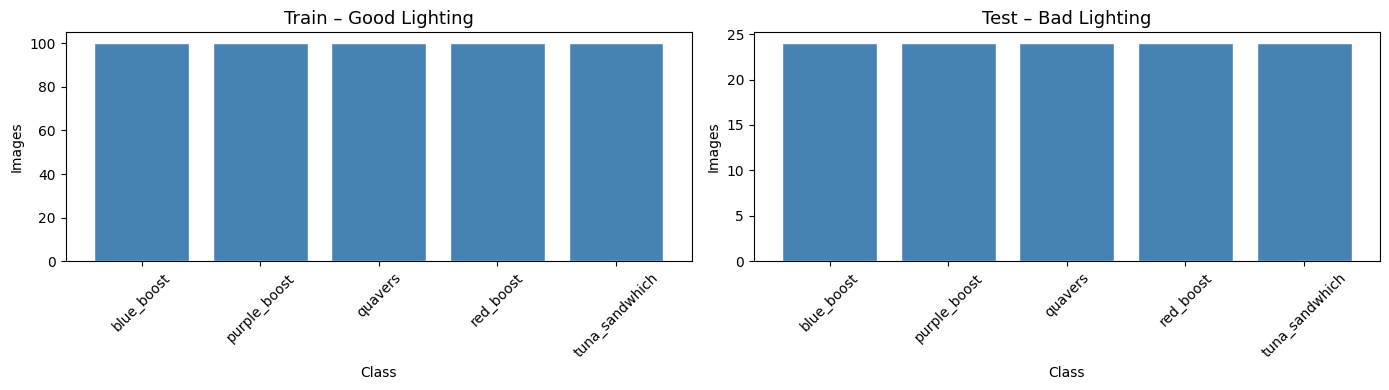

In [26]:
def count_images(root):
    counts = {}
    for cls in sorted(os.listdir(root)):
        cls_path = os.path.join(root, cls)
        if os.path.isdir(cls_path):
            imgs = [f for f in os.listdir(cls_path)
                    if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))]
            counts[cls] = len(imgs)
    return counts

train_counts = count_images(train_path)
test_counts  = count_images(test_path)

print('Train (good lighting):', train_counts)
print('Test  (bad  lighting):', test_counts)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, counts, title in zip(axes,
                              [train_counts, test_counts],
                              ['Train – Good Lighting', 'Test – Bad Lighting']):
    ax.bar(counts.keys(), counts.values(), color='steelblue', edgecolor='white')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Class'); ax.set_ylabel('Images')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

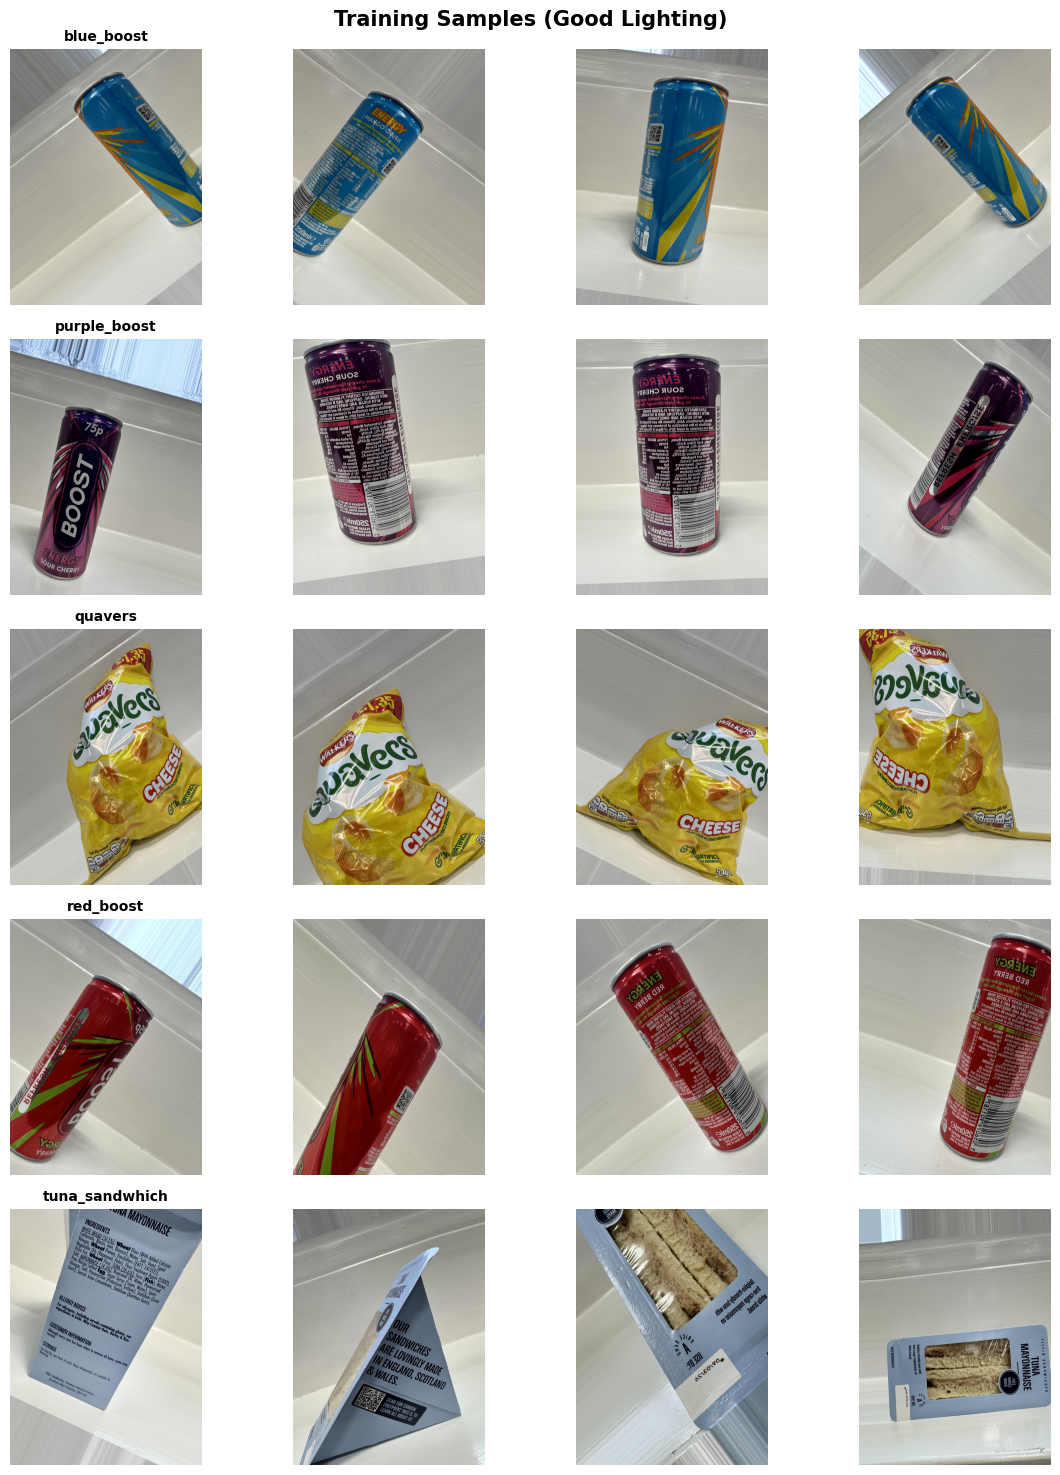

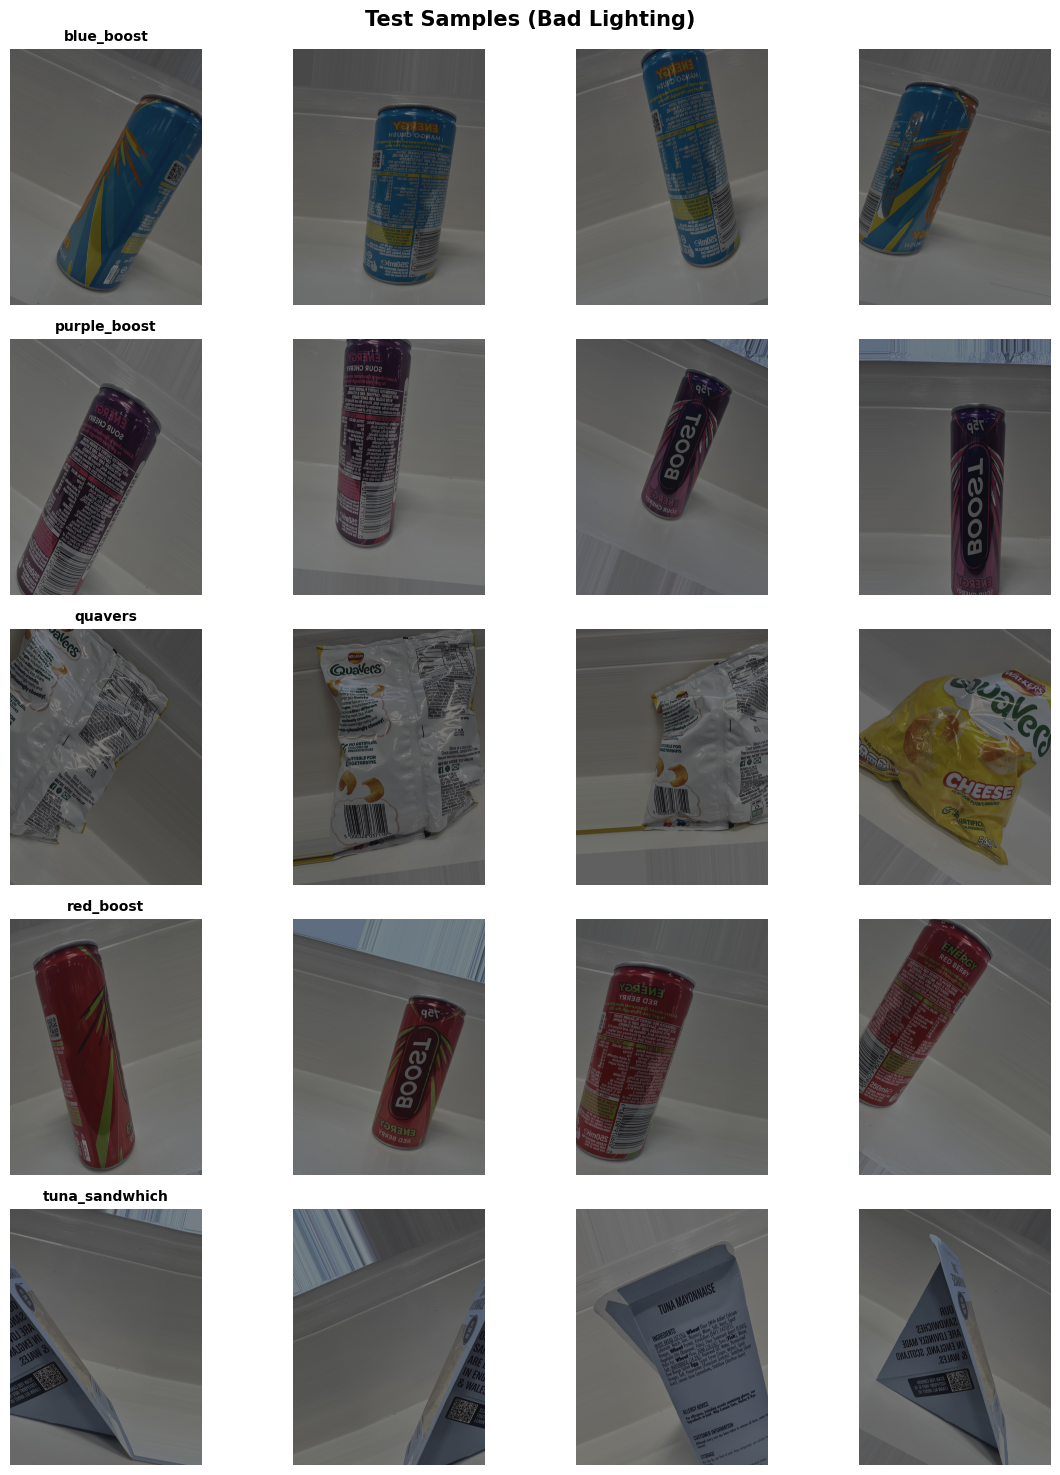

In [28]:
def show_samples(root, n_per_class=4, title=''):
    class_dirs = sorted([d for d in os.listdir(root)
                         if os.path.isdir(os.path.join(root, d)) and not d.startswith('.')])
    n_cols = n_per_class
    n_rows = len(class_dirs)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
    if n_rows == 1: axes = [axes]
    fig.suptitle(title, fontsize=15, fontweight='bold')
    for row, cls in enumerate(class_dirs):
        imgs_dir = os.path.join(root, cls)
        files = [f for f in os.listdir(imgs_dir)
                 if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))]
        sample = random.sample(files, min(n_per_class, len(files)))
        for col, fname in enumerate(sample):
            img = Image.open(os.path.join(imgs_dir, fname)).convert('RGB')
            axes[row][col].imshow(img)
            axes[row][col].axis('off')
            if col == 0:
                axes[row][col].set_title(cls, fontsize=10, fontweight='bold')
    plt.tight_layout(); plt.show()

show_samples(train_path, n_per_class=4, title='Training Samples (Good Lighting)')
show_samples(test_path,  n_per_class=4, title='Test Samples (Bad Lighting)')

## 3. Pixel-Level Analysis — Good vs Bad Lighting

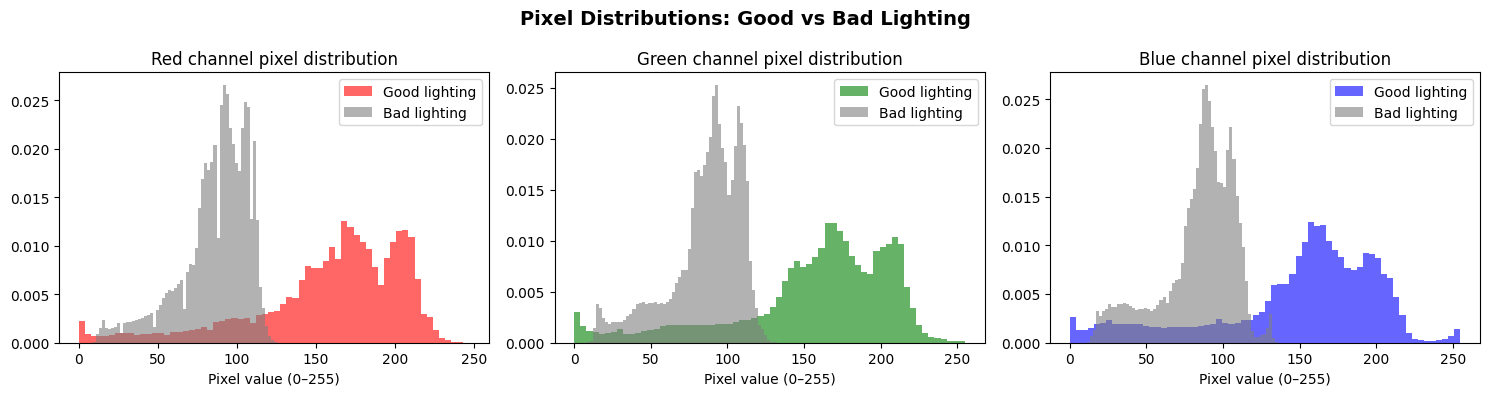

In [29]:
def pixel_stats(root, n_samples=200):
    """Randomly sample images and return flattened pixel arrays per channel."""
    r_all, g_all, b_all = [], [], []
    for cls in os.listdir(root):
        cls_dir = os.path.join(root, cls)
        if not os.path.isdir(cls_dir): continue
        files = [f for f in os.listdir(cls_dir)
                 if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]
        sample = random.sample(files, min(n_samples // max(len(os.listdir(root)),1), len(files)))
        for fname in sample:
            img = np.array(Image.open(os.path.join(cls_dir, fname)).convert('RGB').resize((64,64)))
            r_all.append(img[:,:,0].flatten())
            g_all.append(img[:,:,1].flatten())
            b_all.append(img[:,:,2].flatten())
    return (np.concatenate(r_all),
            np.concatenate(g_all),
            np.concatenate(b_all))

tr_r, tr_g, tr_b = pixel_stats(train_path)
te_r, te_g, te_b = pixel_stats(test_path)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['red', 'green', 'blue']
for ax, (tr, te), ch in zip(axes,
                             [(tr_r,te_r),(tr_g,te_g),(tr_b,te_b)],
                             colors):
    ax.hist(tr, bins=64, alpha=0.6, color=ch,    label='Good lighting', density=True)
    ax.hist(te, bins=64, alpha=0.6, color='gray', label='Bad lighting',  density=True)
    ax.set_title(f'{ch.capitalize()} channel pixel distribution')
    ax.set_xlabel('Pixel value (0–255)'); ax.legend()
plt.suptitle('Pixel Distributions: Good vs Bad Lighting', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Transforms — Operating Directly on Pixels

In [33]:
# All transforms work at the pixel level.
# ToTensor() converts PIL images (0-255 uint8) → float tensors in [0,1].
# Normalize() then standardises each channel.

# Compute per-channel mean & std from training pixels
mean = (
    float(tr_r.mean() / 255),
    float(tr_g.mean() / 255),
    float(tr_b.mean() / 255),
)
std = (
    max(float(tr_r.std() / 255), 1e-6),
    max(float(tr_g.std() / 255), 1e-6),
    max(float(tr_b.std() / 255), 1e-6),
)
print(f'Pixel mean (R,G,B): {mean}')
print(f'Pixel std  (R,G,B): {std}')

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),          # resize to fixed pixel grid
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.ToTensor(),                            # uint8 pixels → float [0,1]
    T.Normalize(mean, std),                  # per-channel pixel normalisation
])

# Test images are bad-lighting — no augmentation, but same pixel normalisation
test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean, std),
])

Pixel mean (R,G,B): (0.6187208655952912, 0.6104887164382798, 0.5797054123495989)
Pixel std  (R,G,B): (0.18865581736967918, 0.20582595330070677, 0.21424899052231647)


## 5. Load Datasets

In [34]:
full_train = ImageFolder(root=train_path, transform=train_transform)
test_ds    = ImageFolder(root=test_path,  transform=test_transform)

# Sanity-check: class index mapping must match between train and test
print('Train class→idx:', full_train.class_to_idx)
print('Test  class→idx:', test_ds.class_to_idx)

# Train / validation split
n_val   = int(len(full_train) * VAL_SPLIT)
n_train = len(full_train) - n_val
train_ds, val_ds = random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

# Give validation set the plain (non-augmented) transform
val_ds.dataset = type(full_train)(root=train_path, transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {n_train} | Val: {n_val} | Test: {len(test_ds)}')

# Show a batch
imgs, lbls = next(iter(train_loader))
print(f'Batch pixels shape : {imgs.shape}   dtype: {imgs.dtype}')
print(f'Pixel value range  : [{imgs.min():.2f}, {imgs.max():.2f}]')

Train class→idx: {'blue_boost': 0, 'purple_boost': 1, 'quavers': 2, 'red_boost': 3, 'tuna_sandwhich': 4}
Test  class→idx: {'blue_boost': 0, 'purple_boost': 1, 'quavers': 2, 'red_boost': 3, 'tuna_sandwhich': 4}
Train: 425 | Val: 75 | Test: 120
Batch pixels shape : torch.Size([32, 3, 224, 224])   dtype: torch.float32
Pixel value range  : [-3.28, 2.02]


## 6. CNN Architecture (Pixel → Class)

In [35]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.25):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout),
        )
    def forward(self, x): return self.block(x)


class PixelCNN(nn.Module):
    """
    Classifies cold-drink images from raw pixel values.
    Input : (B, 3, IMG_SIZE, IMG_SIZE) normalised pixel tensor
    Output: (B, NUM_CLASSES) logits
    """
    def __init__(self, num_classes, img_size=224):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   64,  dropout=0.20),   # → 112×112
            ConvBlock(64,  128, dropout=0.25),   # →  56×56
            ConvBlock(128, 256, dropout=0.25),   # →  28×28
            ConvBlock(256, 256, dropout=0.30),   # →  14×14
            ConvBlock(256, 512, dropout=0.30),   # →   7×7
        )
        feat_dim = 512 * (img_size // 32) * (img_size // 32)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.classifier(self.features(x))


model = PixelCNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')
print(model)

Total parameters: 31,827,781
PixelCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.2, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


## 7. Training Setup

In [36]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0., 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            if training: optimizer.zero_grad(set_to_none=True)
            out  = model(imgs)
            loss = criterion(out, lbls)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * lbls.size(0)
            correct    += (out.argmax(1) == lbls).sum().item()
            total      += lbls.size(0)
    return total_loss / total, correct / total

print('Criterion:', criterion)
print('Optimizer:', optimizer)
print('Scheduler:', scheduler)

Criterion: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.CosineAnnealingLR object at 0x11a601d90>


## 8. Train the Model

In [37]:
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_acc = 0.
best_model_path = os.path.join(base_dir, 'best_pixel_cnn.pth')

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    va_loss, va_acc = run_epoch(val_loader,   training=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    flag = ''
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), best_model_path)
        flag = '  ✓ best'

    print(f'Epoch {epoch:3d}/{NUM_EPOCHS}  '
          f'train loss {tr_loss:.4f} acc {tr_acc:.3f}  '
          f'val loss {va_loss:.4f} acc {va_acc:.3f}  '
          f'{time.time()-t0:.1f}s{flag}')

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Epoch   1/5  train loss 1.8470 acc 0.339  val loss 3.0091 acc 0.387  338.5s  ✓ best
Epoch   2/5  train loss 1.5081 acc 0.416  val loss 1.2109 acc 0.613  334.3s  ✓ best
Epoch   3/5  train loss 1.2458 acc 0.560  val loss 0.7765 acc 0.893  387.5s  ✓ best
Epoch   4/5  train loss 0.8695 acc 0.788  val loss 0.5453 acc 0.987  361.2s  ✓ best
Epoch   5/5  train loss 0.8133 acc 0.807  val loss 0.5101 acc 1.000  360.0s  ✓ best

Best validation accuracy: 1.0000


## 9. Learning Curves

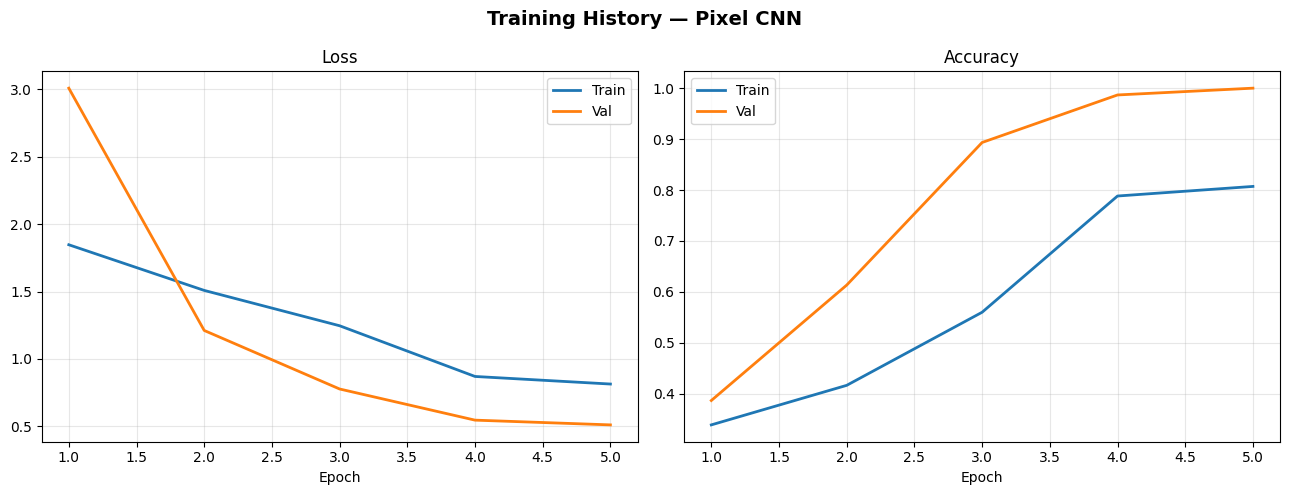

In [38]:
epochs = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(epochs, history['train_loss'], label='Train', linewidth=2)
ax1.plot(epochs, history['val_loss'],   label='Val',   linewidth=2)
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['train_acc'], label='Train', linewidth=2)
ax2.plot(epochs, history['val_acc'],   label='Val',   linewidth=2)
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Training History — Pixel CNN', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 10. Evaluate on Bad-Lighting Test Set

In [39]:
# Load best weights
model.load_state_dict(torch.load(best_model_path, map_location=device))

te_loss, te_acc = run_epoch(test_loader, training=False)
print(f'Test loss : {te_loss:.4f}')
print(f'Test acc  : {te_acc:.4f}  ({te_acc*100:.1f} %)')

Test loss : 0.8639
Test acc  : 0.8250  (82.5 %)


## 11. Per-Class Accuracy Report

Class                 Correct    Total      Acc
------------------------------------------------
blue_boost                 16       24    0.667
purple_boost               22       24    0.917
quavers                    13       24    0.542
red_boost                  24       24    1.000
tuna_sandwhich             24       24    1.000


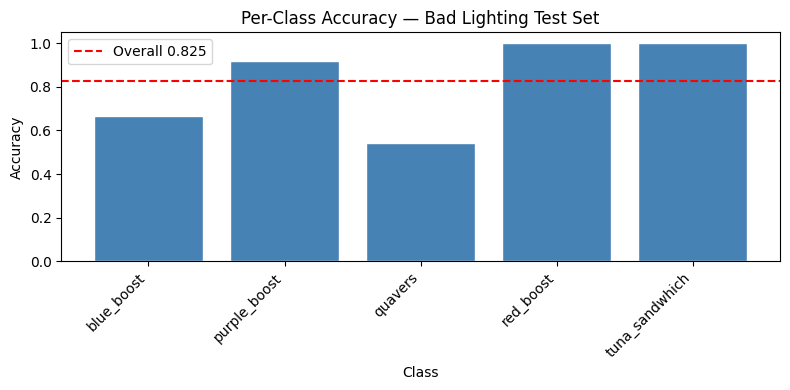

In [40]:
class_correct = np.zeros(NUM_CLASSES)
class_total   = np.zeros(NUM_CLASSES)

model.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        preds = model(imgs).argmax(1)
        for c in range(NUM_CLASSES):
            mask = (lbls == c)
            class_correct[c] += (preds[mask] == c).sum().item()
            class_total[c]   += mask.sum().item()

print('{:<20} {:>8} {:>8} {:>8}'.format('Class', 'Correct', 'Total', 'Acc'))
print('-' * 48)
for c in range(NUM_CLASSES):
    acc = class_correct[c] / max(class_total[c], 1)
    print(f'{idx2class[c]:<20} {int(class_correct[c]):>8} {int(class_total[c]):>8} {acc:>8.3f}')

# Bar chart
accs = [class_correct[c] / max(class_total[c], 1) for c in range(NUM_CLASSES)]
plt.figure(figsize=(max(8, NUM_CLASSES), 4))
bars = plt.bar(list(idx2class.values()), accs, color='steelblue', edgecolor='white')
plt.axhline(te_acc, color='red', linestyle='--', label=f'Overall {te_acc:.3f}')
plt.ylim(0, 1.05); plt.ylabel('Accuracy'); plt.xlabel('Class')
plt.title('Per-Class Accuracy — Bad Lighting Test Set')
plt.xticks(rotation=45, ha='right'); plt.legend(); plt.tight_layout(); plt.show()

## 12. Confusion Matrix

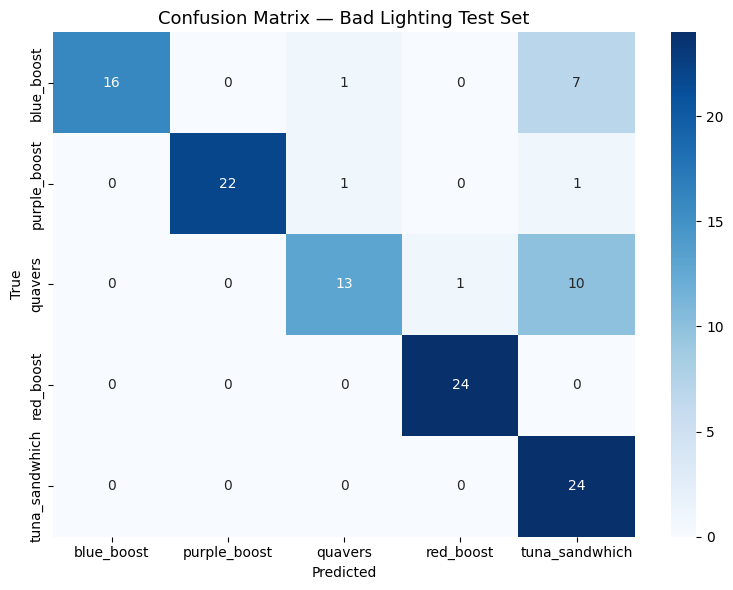

                precision    recall  f1-score   support

    blue_boost       1.00      0.67      0.80        24
  purple_boost       1.00      0.92      0.96        24
       quavers       0.87      0.54      0.67        24
     red_boost       0.96      1.00      0.98        24
tuna_sandwhich       0.57      1.00      0.73        24

      accuracy                           0.82       120
     macro avg       0.88      0.82      0.83       120
  weighted avg       0.88      0.82      0.83       120



In [41]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_preds, all_true = [], []
model.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        preds = model(imgs.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_true.extend(lbls.numpy())

cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(max(8, NUM_CLASSES+2), max(6, NUM_CLASSES)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(idx2class.values()),
            yticklabels=list(idx2class.values()))
plt.title('Confusion Matrix — Bad Lighting Test Set', fontsize=13)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

print(classification_report(all_true, all_preds,
                             target_names=list(idx2class.values())))

## 13. Visual Predictions on Bad-Lighting Images

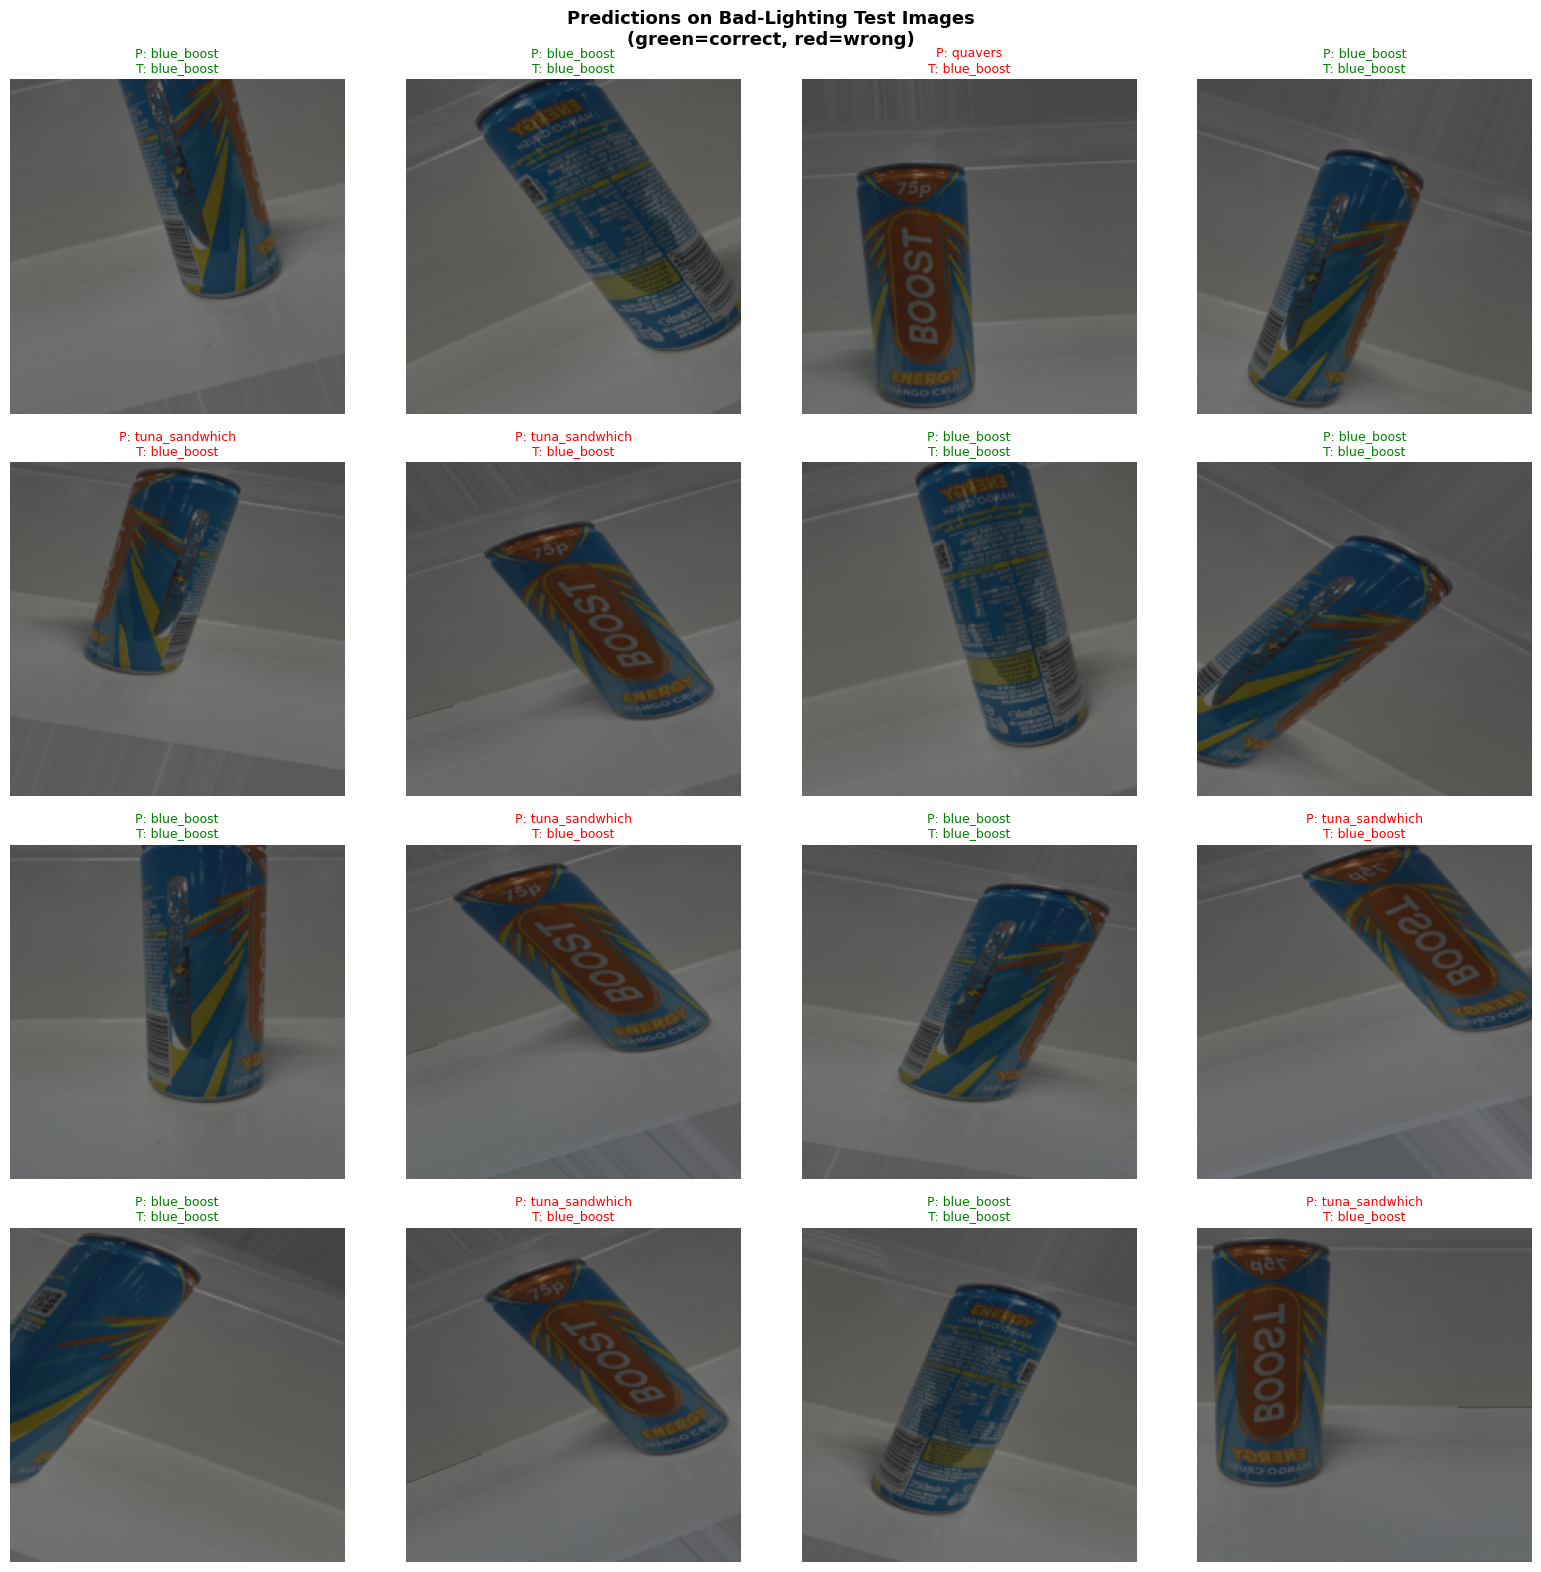

In [42]:
def denorm(t):
    """Reverse the pixel normalisation for display."""
    m = torch.tensor(mean).view(3,1,1)
    s = torch.tensor(std).view(3,1,1)
    return (t * s + m).clamp(0, 1)

imgs_b, lbls_b = next(iter(test_loader))
with torch.no_grad():
    preds_b = model(imgs_b.to(device)).argmax(1).cpu()

n_show = min(16, len(imgs_b))
n_cols = 4
n_rows = (n_show + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten()
for i in range(n_show):
    img = denorm(imgs_b[i]).permute(1,2,0).numpy()
    axes[i].imshow(img)
    pred_lbl = idx2class[preds_b[i].item()]
    true_lbl = idx2class[lbls_b[i].item()]
    color = 'green' if pred_lbl == true_lbl else 'red'
    axes[i].set_title(f'P: {pred_lbl}\nT: {true_lbl}', color=color, fontsize=9)
    axes[i].axis('off')
for j in range(n_show, len(axes)): axes[j].axis('off')
plt.suptitle('Predictions on Bad-Lighting Test Images\n(green=correct, red=wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 14. Save & Reload Model

In [43]:
# Save full checkpoint
checkpoint = {
    'model_state': model.state_dict(),
    'classes':     classes,
    'img_size':    IMG_SIZE,
    'pixel_mean':  mean,
    'pixel_std':   std,
}
ckpt_path = os.path.join(base_dir, 'pixel_cnn_checkpoint.pth')
torch.save(checkpoint, ckpt_path)
print(f'Checkpoint saved → {ckpt_path}')

# ── Reload example ────────────────────────────────────────────────────────
def load_model(ckpt_path):
    ck = torch.load(ckpt_path, map_location=device)
    m  = PixelCNN(num_classes=len(ck['classes']), img_size=ck['img_size']).to(device)
    m.load_state_dict(ck['model_state'])
    m.eval()
    return m, ck

loaded_model, ck = load_model(ckpt_path)
print('Model reloaded successfully.')
print('Classes:', ck['classes'])

Checkpoint saved → /Users/theabood/Desktop/DataScience/semester3/products/pixel_cnn_checkpoint.pth
Model reloaded successfully.
Classes: ['blue_boost', 'purple_boost', 'quavers', 'red_boost', 'tuna_sandwhich']


In [45]:
# Load best weights
model.load_state_dict(torch.load(best_model_path, map_location=device))

bad_test_path   = f'{base_dir}/test'
bad_test_ds     = ImageFolder(root=bad_test_path, transform=test_transform)
bad_test_loader = DataLoader(bad_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

bad_loss, bad_acc = run_epoch(bad_test_loader, training=False)
print(f'[Bad Lighting]  loss: {bad_loss:.4f}  |  acc: {bad_acc:.4f}  ({bad_acc*100:.1f}%)')

[Bad Lighting]  loss: 0.8639  |  acc: 0.8250  (82.5%)


[Good Lighting] loss: 0.5133  |  acc: 0.9917  (99.2%)


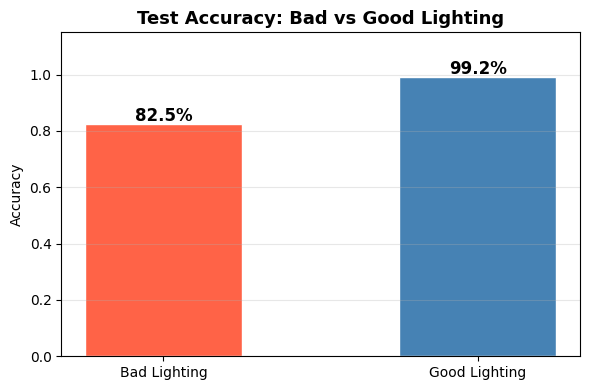

Accuracy gap (good - bad): +16.7%


In [46]:
good_test_path   = f'/Users/theabood/Desktop/DataScience/semester3/Datasets/products/test'
good_test_ds     = ImageFolder(root=good_test_path, transform=test_transform)
good_test_loader = DataLoader(good_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

good_loss, good_acc = run_epoch(good_test_loader, training=False)
print(f'[Good Lighting] loss: {good_loss:.4f}  |  acc: {good_acc:.4f}  ({good_acc*100:.1f}%)')

# Side-by-side accuracy bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Bad Lighting', 'Good Lighting'], [bad_acc, good_acc],
              color=['tomato', 'steelblue'], edgecolor='white', width=0.5)
for bar, val in zip(bars, [bad_acc, good_acc]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val*100:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy')
ax.set_title('Test Accuracy: Bad vs Good Lighting', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Accuracy gap (good - bad): {(good_acc - bad_acc)*100:+.1f}%')